# 01 – Exploratory analysis of the Deep-SE story point data (Week 2)

Run from `notebooks/`. Raw files: `data/raw/*.csv` (fields: issuekey, title, description, storypoint).

In [1]:
import glob, os, sys
import pandas as pd, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '../src')
from eda import summarise, SCALE
files = sorted(glob.glob('../data/raw/*.csv'))
summary = pd.DataFrame([summarise(f) for f in files])
summary

Matplotlib is building the font cache; this may take a moment.


,project,n,no_description,duplicate_text,mean,median,std,min,max,distinct_values,off_scale
0,appceleratorstudio,2919,43,4,5.64,5.0,3.33,1,40,11,5
1,aptanastudio,829,58,0,8.02,8.0,5.95,1,40,12,8
2,bamboo,521,147,2,2.42,2.0,2.14,1,20,9,6
3,clover,384,23,0,4.59,2.0,6.55,1,40,9,6
4,datamanagement,4667,637,56,9.57,4.0,16.60,1,100,79,1933
5,duracloud,666,53,0,2.13,1.0,2.03,1,16,11,23
6,jirasoftware,352,66,68,4.43,3.0,3.51,1,20,8,6
7,mesos,1680,118,0,3.09,3.0,2.42,1,40,10,12
8,moodle,1166,0,0,15.54,8.0,21.65,1,100,16,26
9,mule,889,0,2,5.08,5.0,3.50,1,21,8,10


## Finding 1 – dataset matches the proposal
23,313 issues in 16 projects; no missing story points, no duplicate issue keys.

23313 16


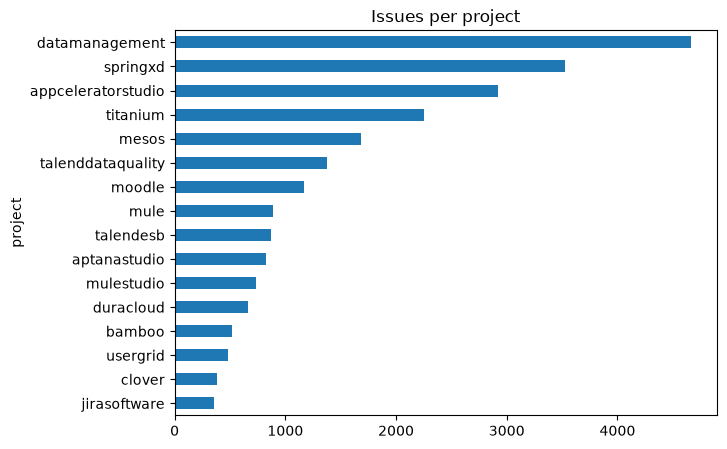

In [2]:
print(summary.n.sum(), len(summary))
summary.set_index('project').n.sort_values().plot.barh(figsize=(7,5), title='Issues per project'); plt.show()

## Finding 2 – label distribution is skewed and not restricted to the planning scale

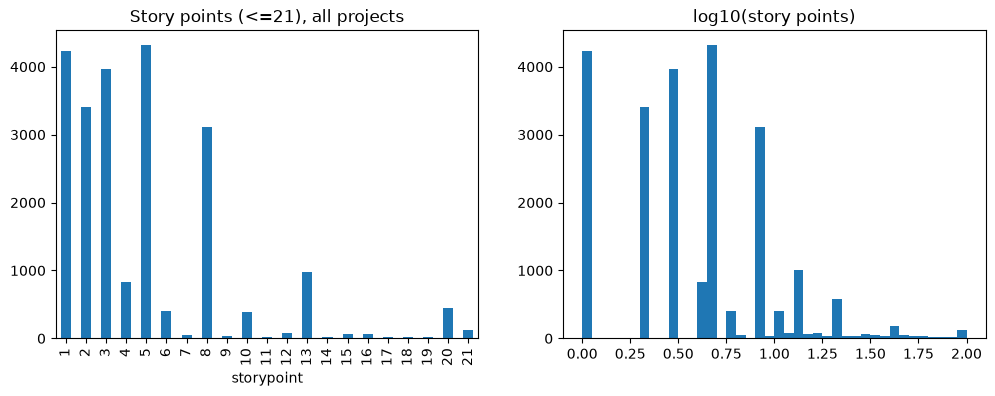

share off planning scale: 10.9%


In [3]:
raw = pd.concat([pd.read_csv(f).assign(project=os.path.basename(f)[:-4]) for f in files])
vc = raw.storypoint.value_counts().sort_index()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
vc[vc.index <= 21].plot.bar(ax=ax[0], title='Story points (<=21), all projects')
ax[1].hist(np.log10(raw.storypoint), bins=40); ax[1].set_title('log10(story points)')
plt.show()
print('share off planning scale: %.1f%%' % (100*(~raw.storypoint.isin(SCALE)).mean()))

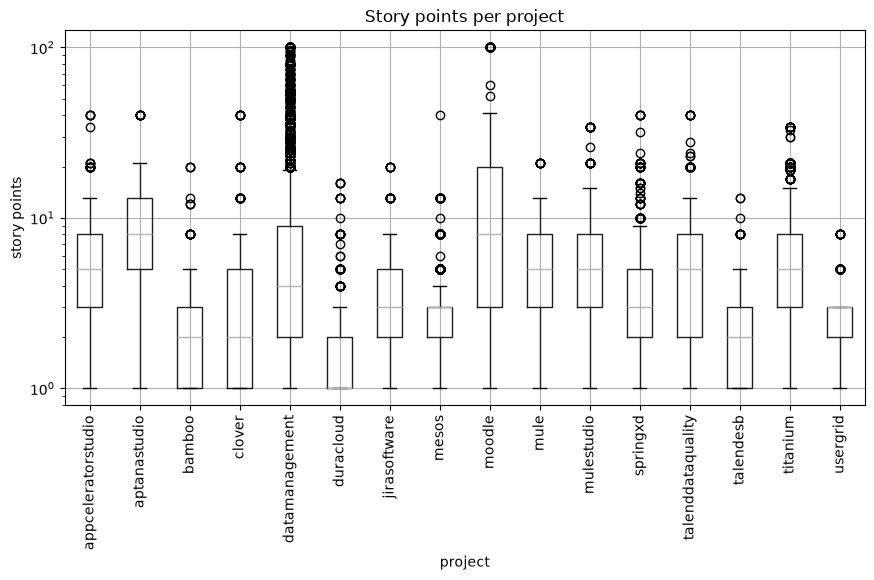

,project,mean,median,std,max,off_scale
0,appceleratorstudio,5.64,5.0,3.33,40,5
1,aptanastudio,8.02,8.0,5.95,40,8
2,bamboo,2.42,2.0,2.14,20,6
3,clover,4.59,2.0,6.55,40,6
4,datamanagement,9.57,4.0,16.60,100,1933
5,duracloud,2.13,1.0,2.03,16,23
6,jirasoftware,4.43,3.0,3.51,20,6
7,mesos,3.09,3.0,2.42,40,12
8,moodle,15.54,8.0,21.65,100,26
9,mule,5.08,5.0,3.50,21,10


In [4]:
raw.boxplot(column='storypoint', by='project', rot=90, figsize=(10,5)); plt.suptitle(''); plt.title('Story points per project'); plt.ylabel('story points'); plt.yscale('log'); plt.show()
summary[['project','mean','median','std','max','off_scale']]

## Finding 3 – text length and missing descriptions

       title_len  desc_len
count    23313.0   23313.0
mean         8.3      68.8
std          3.9     129.1
min          1.0       0.0
25%          6.0      19.0
50%          8.0      40.0
75%         10.0      79.0
max         36.0    3020.0


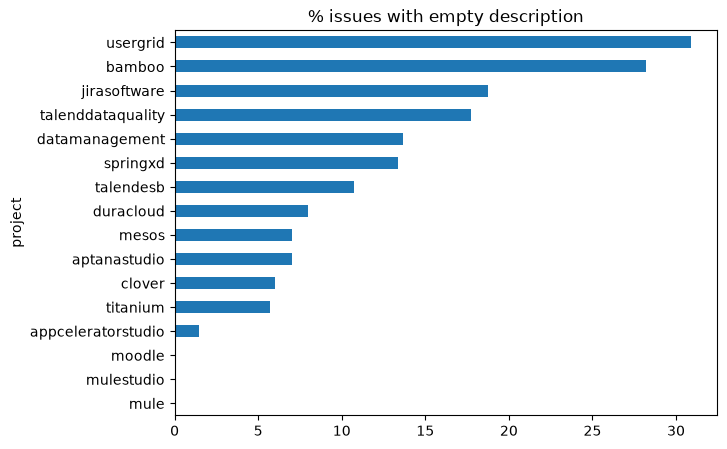

In [5]:
raw['title_len'] = raw.title.fillna('').str.split().str.len()
raw['desc_len'] = raw.description.fillna('').str.split().str.len()
print(raw[['title_len','desc_len']].describe().round(1))
summary.set_index('project').assign(pct_no_desc=lambda d: 100*d.no_description/d.n).pct_no_desc.sort_values().plot.barh(figsize=(7,5), title='% issues with empty description'); plt.show()

## Finding 4 – does text length relate to story points?

In [6]:
raw['words'] = raw.title_len + raw.desc_len
print('Spearman(words, storypoint) overall: %.3f' % raw.words.corr(raw.storypoint, method='spearman'))
raw.groupby('project').apply(lambda g: g.words.corr(g.storypoint, method='spearman')).round(3).sort_values()

Spearman(words, storypoint) overall: 0.099


project
titanium             -0.118
bamboo               -0.093
datamanagement       -0.076
mule                  0.020
mesos                 0.029
duracloud             0.048
jirasoftware          0.102
talenddataquality     0.134
clover                0.138
mulestudio            0.146
talendesb             0.151
moodle                0.159
springxd              0.160
appceleratorstudio    0.166
aptanastudio          0.208
usergrid              0.305
dtype: float64

## Finding 5 – duplicates
Exact duplicate title+description text within a project (can leak between train and test):

In [7]:
summary.set_index('project').duplicate_text[lambda s: s>0].sort_values()

project
usergrid               1
bamboo                 2
mule                   2
springxd               3
appceleratorstudio     4
talenddataquality     29
datamanagement        56
jirasoftware          68
Name: duplicate_text, dtype: int64

## Consequences for Week 3
- No issue-type or creation-date column exists: issue-key number is used as creation order; issue type cannot be a feature.
- Labels are kept as recorded (no snapping to the planning scale); predictions are rounded only for display.
- Empty descriptions are kept (title-only text, flag column); exact duplicate texts are dropped within each project.